# Proprioceptive sensing — object stiffness estimation

The hand squeezes a grasped object with the four fingers held at constant stiffness
$k_{\rm hold}$ = {K_TIP_HOLD} N/m (clamping side).  The thumb alone sweeps through
increasing tip stiffness levels and the resulting position–force finite difference
estimates object compliance without external force sensors.

---

## Why $\Delta x / \Delta F$ recovers $C_O$

At equilibrium, the VMC spring force equals the object reaction force.  Taking the
finite difference between the gentle baseline ($k_1$) and each probe level ($k_2 > k_1$):

$$\Delta x_\text{thumb} = x(k_2) - x(k_1), \qquad \Delta F_\text{thumb} = F(k_2) - F(k_1)$$

$$C_O = \frac{\|\Delta x_\text{thumb}\|}{\|\Delta F_\text{thumb}\|}$$

The hand compliance cancels exactly; lower $C_O$ means stiffer object.

In [2240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys

sys.path.insert(0, os.path.join('../..'))
sys.path.insert(0, '.')
from hand_config import K_TIP_GENTLE, K_TIP_SWEEP, K_TIP_HOLD, N_RUNS, OBJECTS, FINGERTIPS

plt.style.use(os.path.join('../..', 'plot_config.mplstyle'))

OUTPUT_DIR = os.path.join('outputs', 'object_stiffness_hand')

K_TIP_GENTLE = float(K_TIP_GENTLE)
K_TIP_SWEEP  = [float(k) for k in K_TIP_SWEEP]

OBJECT_LABELS = ['Sphere', 'Sponge', 'Yarn']
OBJ_COLORS    = {'hard': '#D55E00', 'medium': '#E69F00', 'soft': '#56B4E9'}


def _sweep_plot(ax, per_run_dict, scale, obj):
    """Per-run dashed lines + mean solid + ±1 std band for one object."""
    k_levels = sorted(per_run_dict.keys())
    vals     = np.array([per_run_dict[k] * scale for k in k_levels])  # (n_k, n_runs)
    mean     = np.nanmean(vals, axis=1)
    std      = np.nanstd(vals,  axis=1)
    color    = OBJ_COLORS[obj]
    name     = OBJECT_LABELS[OBJECTS.index(obj)] if obj in OBJECTS else obj
    for r in range(vals.shape[1]):
        ax.plot(k_levels, vals[:, r], color=color, lw=1.0, linestyle='--', alpha=0.25)
    ax.fill_between(k_levels, mean - std, mean + std, color=color, alpha=0.15)
    ax.plot(k_levels, mean, color=color, label=name)

In [2241]:
def load_runs(obj):
    """Load all run CSV files for an object; fall back to the single-file (video) naming."""
    dfs = []
    for r in range(1, N_RUNS + 1):
        p = os.path.join(OUTPUT_DIR, f'object_stiffness_hand_{obj}_run{r}.csv')
        if os.path.exists(p):
            dfs.append(pd.read_csv(p))
    if not dfs:
        p = os.path.join(OUTPUT_DIR, f'object_stiffness_hand_{obj}.csv')
        if os.path.exists(p):
            dfs.append(pd.read_csv(p))
    return dfs


def _thumb_baseline(df):
    gentle = df[df['k_tip_Npm'] == K_TIP_GENTLE]
    pos_b  = gentle[['tip_thumb_x_m', 'tip_thumb_y_m', 'tip_thumb_z_m']].median().to_numpy()
    F_b    = gentle[['force_1st_thumb_x_N', 'force_1st_thumb_y_N', 'force_1st_thumb_z_N']].median().to_numpy()
    return pos_b, F_b


def compliance_per_run(dfs):
    """Median-based C_O [m/N] for each run at each sweep level.
    Returns dict: k -> 1-D array of length n_runs."""
    out = {k: [] for k in K_TIP_SWEEP}
    for df in dfs:
        pos_b, F_b = _thumb_baseline(df)
        for k in K_TIP_SWEEP:
            sub  = df[df['k_tip_Npm'] == k]
            pos  = sub[['tip_thumb_x_m', 'tip_thumb_y_m', 'tip_thumb_z_m']].median().to_numpy()
            F1   = sub[['force_1st_thumb_x_N', 'force_1st_thumb_y_N', 'force_1st_thumb_z_N']].median().to_numpy()
            nF   = np.linalg.norm(F1 - F_b)
            out[k].append(np.linalg.norm(pos - pos_b) / nF if nF > 1e-12 else np.nan)
    return {k: np.array(v) for k, v in out.items()}


def displacement_per_run(dfs):
    """Median thumb displacement [m] from baseline per run at each sweep level."""
    out = {k: [] for k in K_TIP_SWEEP}
    for df in dfs:
        pos_b, _ = _thumb_baseline(df)
        for k in K_TIP_SWEEP:
            sub = df[df['k_tip_Npm'] == k]
            pos = sub[['tip_thumb_x_m', 'tip_thumb_y_m', 'tip_thumb_z_m']].median().to_numpy()
            out[k].append(np.linalg.norm(pos - pos_b))
    return {k: np.array(v) for k, v in out.items()}


def force_per_run(dfs):
    """Median thumb force change [N] from baseline per run at each sweep level."""
    out = {k: [] for k in K_TIP_SWEEP}
    for df in dfs:
        _, F_b = _thumb_baseline(df)
        for k in K_TIP_SWEEP:
            sub = df[df['k_tip_Npm'] == k]
            F1  = sub[['force_1st_thumb_x_N', 'force_1st_thumb_y_N', 'force_1st_thumb_z_N']].median().to_numpy()
            out[k].append(np.linalg.norm(F1 - F_b))
    return {k: np.array(v) for k, v in out.items()}


# ── Load data ──────────────────────────────────────────────────────────────────
data = {}
print('Loading data:')
for obj in OBJECTS:
    dfs = load_runs(obj)
    if not dfs:
        print(f'  {obj:<10s}: no data')
        continue
    data[obj] = dict(
        dfs        = dfs,
        compliance = compliance_per_run(dfs),
        displ      = displacement_per_run(dfs),
        force      = force_per_run(dfs),
    )
    print(f'  {obj:<10s}: {len(dfs)} run(s)')

Loading data:
  hard      : 5 run(s)
  medium    : 5 run(s)
  soft      : 5 run(s)


## Thumb object compliance $C_O$ vs $k_{tip}$

$C_O = \|\Delta x_{\rm thumb}\| / \|\Delta F_{\rm thumb}\|$ — lower = stiffer object. Dashed lines = individual trials, solid = mean, band = ±1 std.

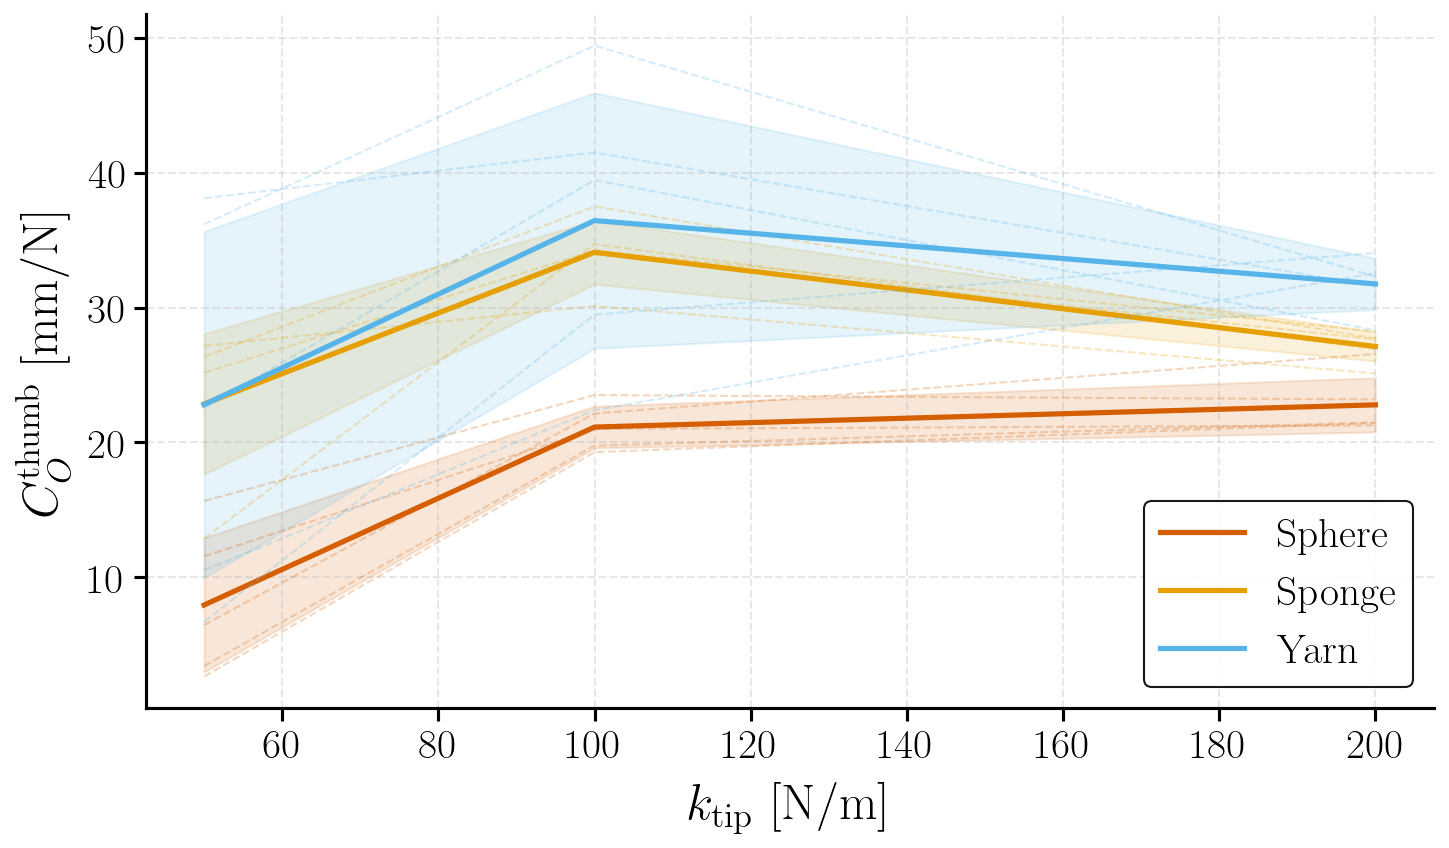

In [2242]:
fig, ax = plt.subplots()
for obj in OBJECTS:
    if obj not in data:
        continue
    _sweep_plot(ax, data[obj]['compliance'], 1e3, obj)
ax.set_xlabel(r'$k_\mathrm{tip}$ [N/m]')
ax.set_ylabel(r'$C_O^{\mathrm{thumb}}$ [mm/N]')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_compliance_sweep.pdf'))
plt.show()

## Thumb tip displacement $\|\Delta x_{\rm thumb}\|$ vs $k_{tip}$

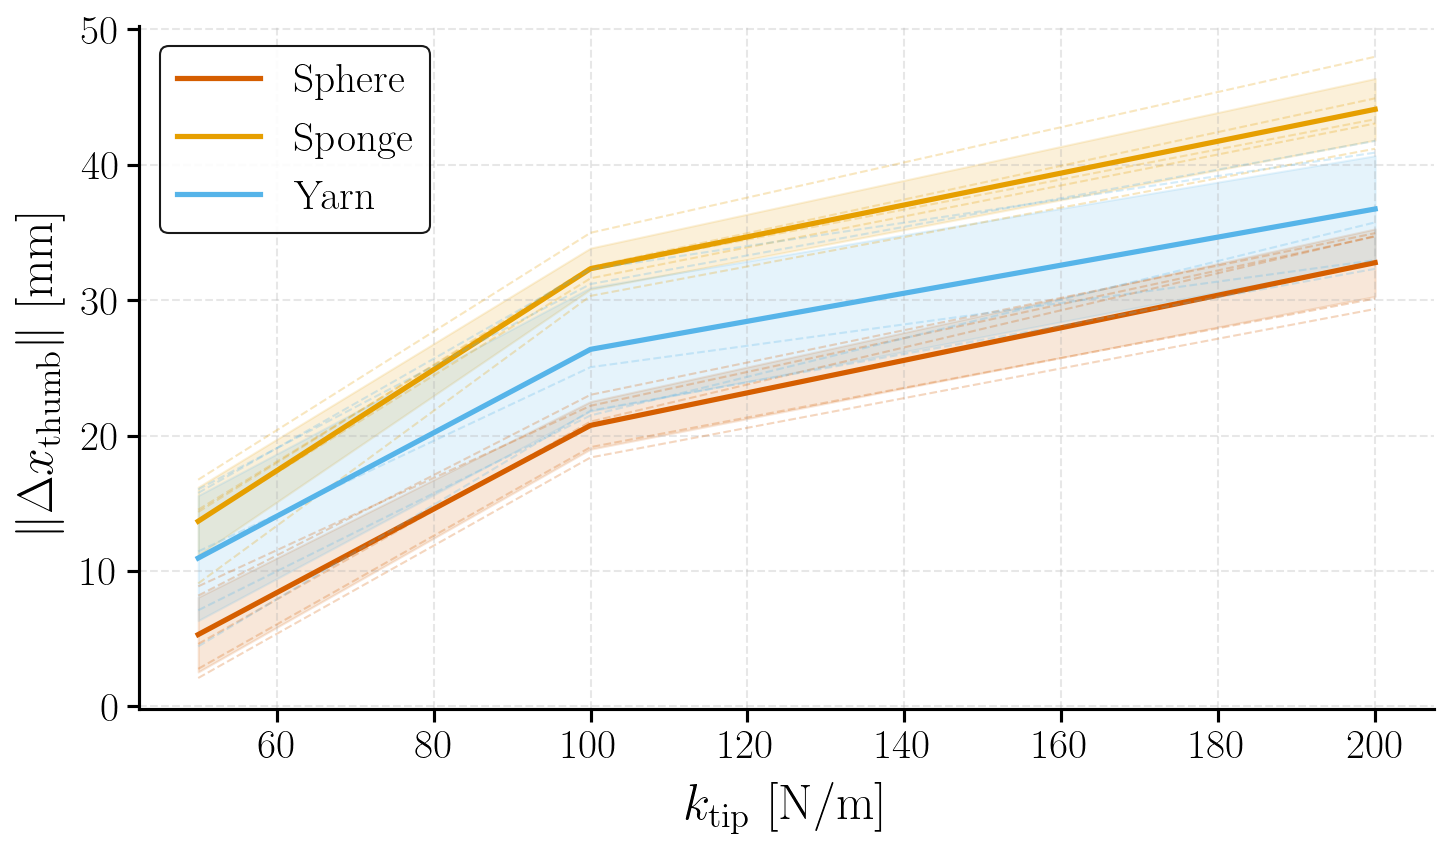

In [2243]:
fig, ax = plt.subplots()
for obj in OBJECTS:
    if obj not in data:
        continue
    _sweep_plot(ax, data[obj]['displ'], 1e3, obj)
ax.set_xlabel(r'$k_\mathrm{tip}$ [N/m]')
ax.set_ylabel(r'$\|\Delta x_{\mathrm{thumb}}\|$ [mm]')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_displacement_sweep.pdf'))
plt.show()

## Thumb contact force $\|\Delta F_{\rm thumb}\|$ vs $k_{tip}$

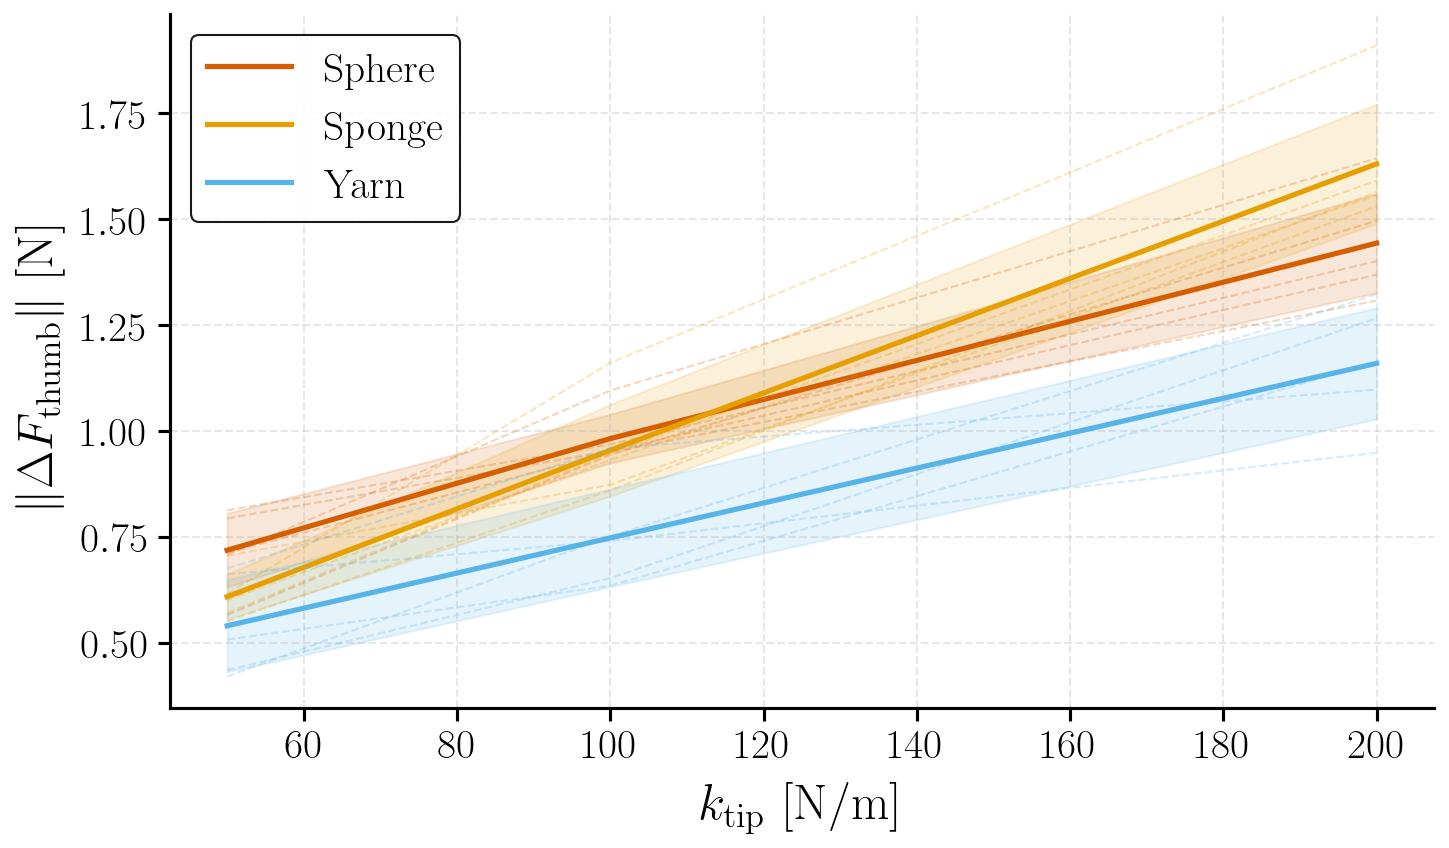

In [2244]:
fig, ax = plt.subplots()
for obj in OBJECTS:
    if obj not in data:
        continue
    _sweep_plot(ax, data[obj]['force'], 1.0, obj)
ax.set_xlabel(r'$k_\mathrm{tip}$ [N/m]')
ax.set_ylabel(r'$\|\Delta F_{\mathrm{thumb}}\|$ [N]')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_force_sweep.pdf'))
plt.show()

## Object classification by thumb compliance

$C_O^{\mathrm{thumb}}$ at each $k_\mathrm{tip}$ — lower = stiffer. Dots = individual trials, filled marker = mean $\pm$ std.

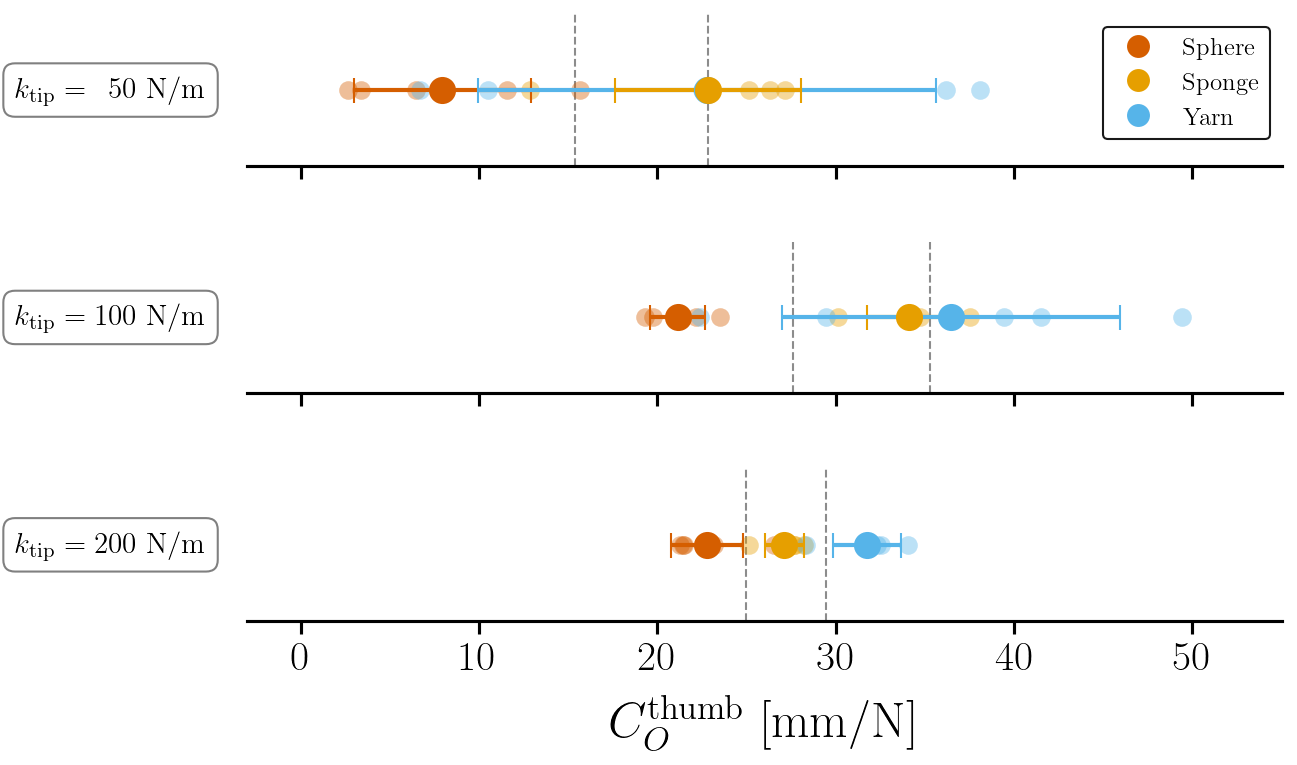


k_tip = 50 N/m
  Sphere      7.94 ± 4.970 mm/N
  Yarn        22.80 ± 12.846 mm/N
  Sponge      22.85 ± 5.215 mm/N

k_tip = 100 N/m
  Sphere      21.14 ± 1.550 mm/N
  Sponge      34.11 ± 2.360 mm/N
  Yarn        36.46 ± 9.483 mm/N

k_tip = 200 N/m
  Sphere      22.79 ± 2.011 mm/N
  Sponge      27.12 ± 1.086 mm/N
  Yarn        31.76 ± 1.901 mm/N


In [2245]:
def _classification_subplot(ax, C_O_runs_local):
    sorted_objs = sorted(C_O_runs_local, key=lambda o: np.nanmean(C_O_runs_local[o]))
    stats = {obj: (float(np.nanmean(C_O_runs_local[obj])), float(np.nanstd(C_O_runs_local[obj])))
             for obj in sorted_objs}
    means      = [stats[o][0] for o in sorted_objs]
    thresholds = [(means[i] + means[i+1]) / 2 for i in range(len(means) - 1)]
    for obj in sorted_objs:
        vals  = C_O_runs_local[obj]
        m, s  = stats[obj]
        color = OBJ_COLORS[obj]
        ax.scatter(vals, np.zeros_like(vals), color=color, s=80, alpha=0.4, zorder=4, lw=0)
        ax.errorbar([m], [0], xerr=[[s], [s]],
                    fmt='o', color=color, ms=12, capsize=6, lw=2.0, zorder=5)
    for thr in thresholds:
        ax.axvline(thr, color='0.55', lw=1.0, linestyle='--')
    ax.set_yticks([])
    ax.spines[['left', 'top', 'right']].set_visible(False)
    ax.grid(False)
    return stats


conditions = [
    (k, {obj: data[obj]['compliance'][k] * 1e3
         for obj in OBJECTS if obj in data and k in data[obj]['compliance']})
    for k in K_TIP_SWEEP
]

n_cond = len(conditions)
fig, axes = plt.subplots(n_cond, 1, figsize=(10, 1.75 * n_cond), sharex=True)
if n_cond == 1:
    axes = [axes]

fig.subplots_adjust(left=0.28, right=0.97, hspace=0.5, top=0.95, bottom=0.18)

all_vals = [v for _, c in conditions for vals in c.values() for v in vals]
margin   = (max(all_vals) - min(all_vals)) * 0.12
xlim     = (min(all_vals) - margin, max(all_vals) + margin)

max_digits = len(str(int(max(K_TIP_SWEEP))))

results = []
for ax, (k, c_runs) in zip(axes, conditions):
    stats = _classification_subplot(ax, c_runs)
    ax.set_xlim(xlim)
    n_digits = len(str(int(k)))
    phantom  = r'\phantom{' + '0' * (max_digits - n_digits) + r'}' if n_digits < max_digits else ''
    ax.text(-0.04, 0.5,
            rf'$k_{{\mathrm{{tip}}}} = {phantom}{k:.0f}\ \mathrm{{N/m}}$',
            transform=ax.transAxes, ha='right', va='center', fontsize=14,
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='0.5', lw=1.0),
            clip_on=False)
    results.append((k, c_runs, stats))

axes[-1].set_xlabel(r'$C_O^{\mathrm{thumb}}$ [mm/N]')

legend_handles = [
    mpl.lines.Line2D([0], [0], marker='o', color=OBJ_COLORS[obj],
                     linestyle='', ms=10, label=OBJECT_LABELS[OBJECTS.index(obj)])
    for obj in OBJECTS if obj in data
]
axes[0].legend(handles=legend_handles, loc='upper right', fontsize=12)

os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'object_classification.pdf'))
plt.show()

for k, c_runs, stats in results:
    print(f'\nk_tip = {k:.0f} N/m')
    for obj in sorted(c_runs, key=lambda o: np.nanmean(c_runs[o])):
        oi   = OBJECTS.index(obj)
        name = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
        m, s = stats[obj]
        print(f'  {name:<10s}  {m:.2f} ± {s:.3f} mm/N')

---

## Dynamic stiffness ramp — transient response

The thumb tip stiffness is ramped from `K_TIP_GENTLE` → `K_TIP_PROBE` at different
speeds (`RAMP_DURATIONS`).  The four clamping fingers stay frozen at `K_TIP_HOLD`.
Each CSV contains three phases: `baseline` (before ramp), `ramp` (during the K step),
`post_ramp` (after reaching `K_TIP_PROBE`).

Time is zeroed at the start of the baseline window for each condition.


In [2246]:
from glob import glob
from hand_config import K_TIP_PROBE, RAMP_DURATIONS, POST_RAMP_DURATION, BASELINE_DURATION

DYN_DIR = os.path.join('outputs', 'object_stiffness_dynamic')

# Ramp-duration label for plots (ms)
DUR_LABELS  = [f'{int(round(d * 1000))} ms' for d in RAMP_DURATIONS]
DUR_COLORS  = plt.cm.viridis(np.linspace(0.15, 0.90, len(RAMP_DURATIONS)))


def load_dynamic(obj):
    """Return dict dur_s -> list[DataFrame], one df per run."""
    out = {}
    for dur in RAMP_DURATIONS:
        tag = f'{int(round(dur * 1000))}ms'
        dfs = []
        # multi-run files first
        for r in range(1, N_RUNS + 1):
            p = os.path.join(DYN_DIR, f'object_stiffness_dynamic_{obj}_dur{tag}_run{r}.csv')
            if os.path.exists(p):
                dfs.append(pd.read_csv(p))
        # single-run fallback
        if not dfs:
            p = os.path.join(DYN_DIR, f'object_stiffness_dynamic_{obj}_dur{tag}.csv')
            if os.path.exists(p):
                dfs.append(pd.read_csv(p))
        if dfs:
            out[dur] = dfs
    return out


dyn_data = {}
print('Loading dynamic data:')
for obj in OBJECTS:
    d = load_dynamic(obj)
    if d:
        dyn_data[obj] = d
        counts = {dur: len(dfs) for dur, dfs in d.items()}
        print(f'  {obj:<10s}: {counts}')
    else:
        print(f'  {obj:<10s}: no data')


Loading dynamic data:
  hard      : {0.01: 5, 0.0193: 5, 0.0373: 5, 0.072: 5, 0.1389: 5, 0.2683: 5, 0.5179: 5, 1.0: 5}
  medium    : {0.01: 5, 0.0193: 5, 0.0373: 5, 0.072: 5, 0.1389: 5, 0.2683: 5, 0.5179: 5, 1.0: 5}
  soft      : {0.01: 5, 0.0193: 5, 0.0373: 5, 0.072: 5, 0.1389: 5, 0.2683: 5, 0.5179: 5, 1.0: 5}


### Estimated compliance $C_O$ vs ramp duration

$C_O = \|\Delta x_\mathrm{thumb}\|_\mathrm{peak} \;/\; \|\Delta F_\mathrm{thumb}\|_{t_\mathrm{peak}}$ — displacement and force evaluated at the same instant of maximum displacement, relative to baseline. One curve per object, mean $\pm$ std across trials.

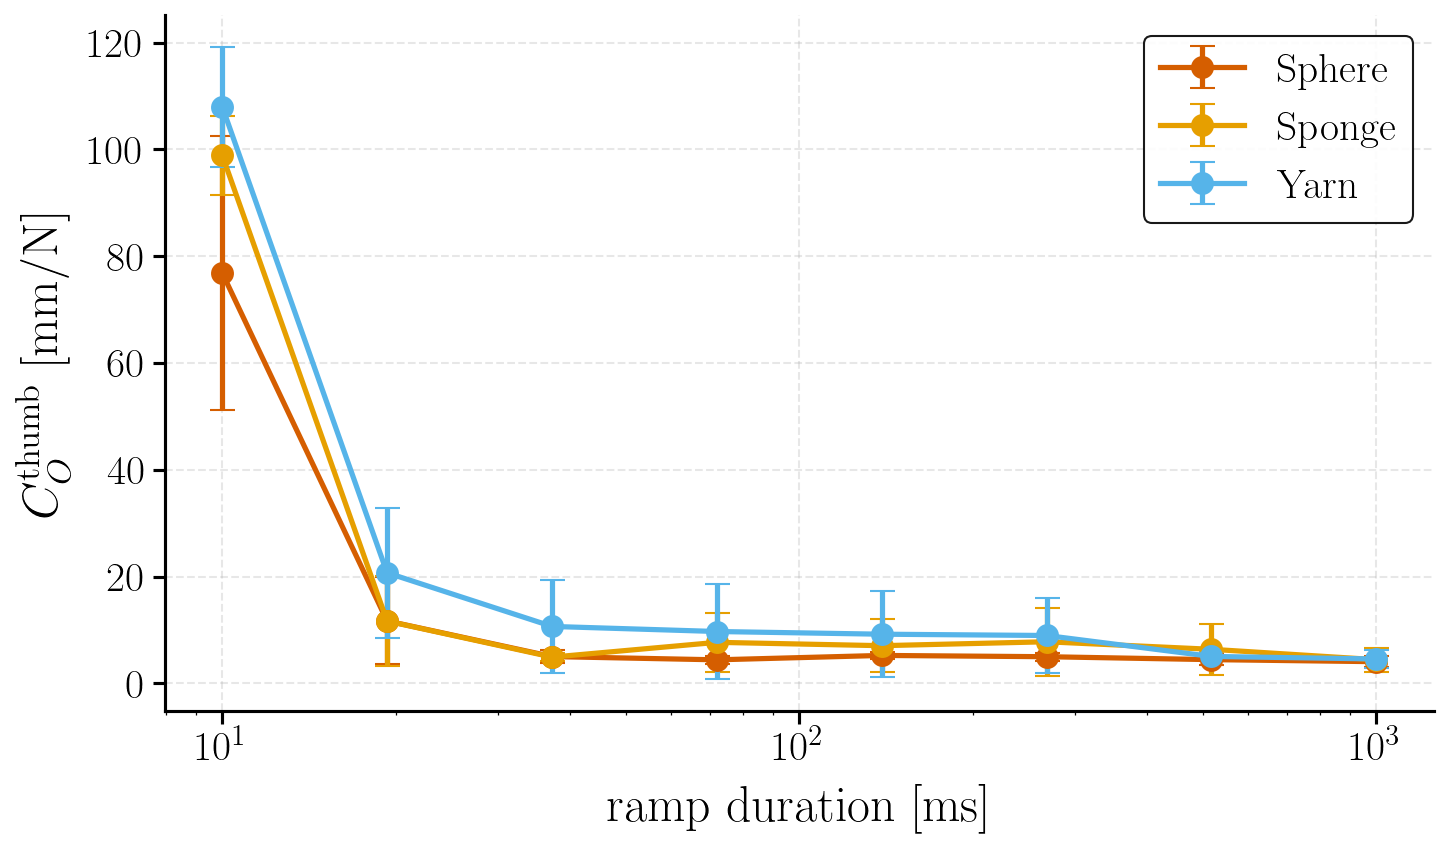

In [2247]:
def _dyn_compliance_per_dur(dfs_by_dur):
    """C_O [mm/N]: displacement at peak-displacement instant / force at that same instant."""
    _POS_COLS = [f'tip_thumb_{a}_m'       for a in 'xyz']
    _F_COLS   = [f'force_1st_thumb_{a}_N' for a in 'xyz']
    out = {}
    for dur, dfs in dfs_by_dur.items():
        co_list = []
        for df in dfs:
            base   = df[df['phase'] == 'baseline']
            active = df[df['phase'].isin(['ramp', 'post_ramp'])]
            if base.empty or active.empty:
                co_list.append(np.nan)
                continue
            pos_b = base[_POS_COLS].median().to_numpy()
            F_b   = base[_F_COLS].median().to_numpy()
            disp  = np.linalg.norm(active[_POS_COLS].to_numpy() - pos_b, axis=1)
            force = np.linalg.norm(active[_F_COLS].to_numpy()   - F_b,   axis=1)
            idx_peak   = np.argmax(disp)
            peak_disp  = disp[idx_peak]
            peak_force = force[idx_peak]
            co_list.append(peak_disp / peak_force * 1e3 if peak_force > 1e-12 else np.nan)
        out[dur] = np.array(co_list)
    return out


if dyn_data:
    fig, ax = plt.subplots()
    for obj in OBJECTS:
        if obj not in dyn_data:
            continue
        color = OBJ_COLORS[obj]
        oi    = OBJECTS.index(obj)
        name  = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
        co    = _dyn_compliance_per_dur(dyn_data[obj])
        durs  = sorted(co.keys())
        means = [np.nanmean(co[d]) for d in durs]
        stds  = [np.nanstd(co[d])  for d in durs]
        durs_ms = [d * 1000 for d in durs]
        ax.errorbar(durs_ms, means, yerr=stds,
                    fmt='o-', color=color, capsize=6, label=name)
    ax.set_xlabel(r'ramp duration [ms]')
    ax.set_ylabel(r'$C_O^{\mathrm{thumb}}$ [mm/N]')
    ax.set_xscale('log')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    os.makedirs(DYN_DIR, exist_ok=True)
    fig.savefig(os.path.join(DYN_DIR, 'dyn_compliance_vs_ramp_dur.pdf'))
    plt.show()
else:
    print('No dynamic data found.')